# Object Detection + VLMs(Visual Language Models)

⸻

## Contents

1. Setup
    * module import
    * path import
    * util function
2. Configuration
3. VLM Tool
4. Initial detection & Annotated image visualization
5. 

⸻

### 1. Setup 

Module import

In [ ]:
# basic module
import os, sys, copy

# data handling / io
import numpy as np
import pandas as pd
import json, base64

# image handling
from PIL import Image, ImageDraw, ImageFont
import cv2 # 박스 그리기/ 좌표 변환 
import torch

# LLM
from openai import OpenAI
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from PIL import Image, ImageDraw, ImageFont

# Utils
from tqdm import tqdm
import time, argparse, logging, uuid
from dotenv import load_dotenv

Path import

In [ ]:
# 경로/출력 폴더 생성 (나중에 find_project_root() 호출 후 사용)
def ensure_dir(path):
    # 디렉토리 없으면 생성
    os.makedirs(path, exist_ok=True)

def get_project_path(*paths):
    project_root = os.getcwd()    # or use a specific absolute path if needed
    return os.path.join(project_root, *paths)


Util function

In [ ]:
# project root 
def find_project_root(marker_filename=".project-root"):
    current_dir = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current_dir, marker_filename)):
            return current_dir
        parent_dir = os.path.dirname(current_dir)
        if parent_dir == current_dir:
            raise FileNotFoundError(f"Could not find {marker_filename} in any parent directory.")
        current_dir = parent_dir

In [16]:
# b64 encoder: jpg image -> base64 string / VLM API
def encode_image_to_base64(img_path):
    try: 
        with open(img_path, "rb") as image_file:
            return base64.b64encode(image_file.read()).decode("utf-8")
    except Exception as e:
        print(f"Error encoding image.: {e}")
        return None

In [ ]:
# example: base64 encoding
input_img_path = os.path.join(os.getcwd(), "data_notebook", "i_0.jpg")
output_img_path = os.path.join(os.getcwd(), "output_notebook", "o_0.jpg")

b64str = encode_image_to_base64(input_img_path) 
print("인코딩 문자열의 앞 50자: ")
print(b64str[:50]) 

인코딩 문자열의 앞 50자: 
/9j/4AAQSkZJRgABAQEBLAEsAAD/7Sm+UGhvdG9zaG9wIDMuMA


In [ ]:
# 화살표, 숫자 표시
def draw_arrows_and_numbers(image_path, detected_objects):
    """
    Draws arrows and numbers on an image to label detected objects.
    """
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    font = cv2.FONT_HERSHEY_SIMPLEX
    used_positions = []

    # Pad the image with a white border
    top, bottom, left, right = 50, 50, 50, 50
    img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[255, 255, 255])

    height, width, _ = img.shape

    for i, (num, obj, box) in enumerate(detected_objects):
        x1, y1, x2, y2 = map(int, box)
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2  # Center of the bounding box

        # Adjust coordinates for padded image
        x1 += left
        y1 += top
        x2 += left
        y2 += top
        cx += left
        cy += top

        # Determine arrow direction towards the nearest border
        distances = {'top': cy, 'bottom': height - cy, 'left': cx, 'right': width - cx}
        direction = min(distances, key=distances.get)

        if direction == 'top':
            arrow_end = (cx, top)
            text_position = (cx - 10, top - 10)
        elif direction == 'bottom':
            arrow_end = (cx, height - bottom)
            text_position = (cx - 10, height - 5)
        elif direction == 'left':
            arrow_end = (left, cy)
            text_position = (left - 30, cy + 5)
        else:
            arrow_end = (width - right, cy)
            text_position = (width - 30, cy + 5)

        # Draw the dashed arrow from the object center to the border
        color = (0, 0, 0)  # Black color for all arrows
        line_type = cv2.LINE_4
        cv2.arrowedLine(img, (cx, cy), arrow_end, color, 2, tipLength=0.3)

        # Draw a semi-transparent rectangle behind the text
        overlay = img.copy()
        cv2.rectangle(overlay, (text_position[0] - 5, text_position[1] - 20), (text_position[0] + 30, text_position[1] + 5), (0, 0, 0), -1)
        alpha = 0.5
        cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0, img)

        # Draw the number at the border with black text
        cv2.putText(img, str(num), text_position, font, 0.5, color, 2)

    # Create dynamic output path based on input image path
    base_name = os.path.basename(image_path)
    name_part, ext_part = os.path.splitext(base_name)
    output_filename = f"labeled_objects_{name_part}{ext_part}"
    
    # Correctly construct the path relative to the notebook's location
    output_dir = os.path.join(os.getcwd(), "output_notebook")
    os.makedirs(output_dir, exist_ok=True)
    labeled_image_path = os.path.join(output_dir, output_filename)
    
    cv2.imwrite(labeled_image_path, img)
    return labeled_image_path

In [ ]:
"""
# example
# 로그 파일 설정 (스크립트와 같은 폴더에 my_exp.log 생성)
logging.basicConfig(
    filename='my_exp.log',
    level=logging.INFO,
    format='%(asctime)s:%(levelname)s:%(message)s'
)

# 임시로 저장할 결과 폴더 생성
output_dir = "results"
os.makedirs(output_dir, exist_ok=True)

# 진행바와 함께 파일 생성 및 로그 남기기 예시
for idx in tqdm(range(5), desc="Processing"):
    unique_name = f"result_{uuid.uuid4()}.txt"
    file_path = os.path.join(output_dir, unique_name)

    # 더미 데이터 파일 생성
    with open(file_path, 'w') as f:
        f.write(f"이 파일은 {idx}번째로 생성된 임시 파일입니다.\n")

    logging.info(f"{idx}번째 작업, 결과 파일: {file_path}")
    time.sleep(1)  # 시간 지연(실제 작업 대체용)

logging.info("모든 작업 완료")
print("실행이 끝났습니다. 'my_exp.log'에서 로그를 확인하세요.")
"""

Processing:  20%|██        | 1/5 [00:02<00:08,  2.00s/it]


KeyboardInterrupt: 

⸻

### 2. Configuration

In [ ]:
# === Configuration ===

# 1. 입력 이미지 경로, 출력 디렉토리 지정
input_img_path = os.path.join(os.getcwd(), "data_notebook", "i_0.jpg")
output_img_path = os.path.join(os.getcwd(), "output_notebook", "o_0.jpg")


# 2. detectcor / device/ threshold / 최대 박스 수
MODEL_TYPES = {
    "owlvit": "google/owlvit-base-patch32",
    "grounding_dino": "IDEA-Research/grounding-dino-tiny",} # 모델 로드
DEFAULT_MODEL_TYPE = "grounding_dino"
MODEL_ID = MODEL_TYPES[DEFAULT_MODEL_TYPE]
INV_MODEL_TYPES = {v:k for k,v in MODEL_TYPES.items()} # 모델 별칭 딕셔너리

# device config
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# detection config
CONFIDENCE_THRESHOLD = 0.2
MAX_BOXES = 20


# 3. VLM 모델명(개념 추출: gpt-4o, 질의 비평: o1, 최종 검증: gpt-4o), 토큰/온도 등
CONCEPT_EXTRACTION_VLM = "gpt-4.1"  # 초기 개념 추출
CRITIQUE_VLM = "gpt-4o"            # 쿼리 비평 및 개선
VALIDATION_VLM = "gpt-4.1"         # 최종 검증


# 4. 숫자 라벨/ 패딩 옵션, 폰트/두께, 색
COLOR_PALETTE = [
    "red", "blue", "green", "purple", "orange", 
    "cyan", "magenta", "yellow", "brown", "pink"]
FONT_PATH = "fonts/arial.ttf"

IMAGE_EXTENSIONS = ("jpg", "jpeg", "png")
DRAW_FONT_SIZE = 22
DRAW_LABEL_LANG = "en"      # 'en' or 'ko'

LABEL_BOX_COLOR = "red"
LABEL_FONT_SIZE = 18
LABEL_LINE_WIDTH = 3

# 5. chatGPT API key
project_root = find_project_root()
dotenv_path = os.path.join(project_root, ".env")


⸻

### 3. VLM Tool

* Input
    * Image(path/ base64)
    * User request
* Output
    * Object: [str]

In [70]:
# === VLM Tool ===
class VLMTool:
    def __init__(self, api_key):
        self.client = OpenAI(api_key=api_key)

In [71]:
# 1. chat completion: VLM API 요청, 응답 저장
def model_response(self, messages, model="gpt-4.1", temperature=0.1, max_tokens=1000, response_format=None):
    try: 
        # 텍스트 생성 요청
        if model in ["gpt-4.1", "gpt-4o"]:
            response = self.client.chat.completions.create(
                model=model,
                messages=messages,
                max_completion_tokens=max_tokens,
                response_format=response_format if response_format else {"type": "text"},
                temperature=temperature
            ) # open ai class method
        else: 
            raise NotImplementedError("This model is not supported")
        
        # 응답 추출
        return response.choices[0].message.content # open ai 응답 메시지 리스트 중 첫 번쨰 답변만

    except Exception as e:
        print(f"Error calling LLM: {e}")
        return None
VLMTool.model_response = model_response

# 2. extract objects from request: 탐지 객체 목록 문자열 리스트로 추출
def extract_objects_from_request(self, image_path, user_text, model="gpt-4.1"):
    try:
        base64_image = encode_image_to_base64(image_path)
        if not base64_image:
            return None

        # prompt
        prompt = (
            "You are an AI assistant that identifies the primary subject for an object detection task from a user's request. "
            "Your goal is to extract ONLY the main object(s) the user wants to find, including their specific attributes like color or state. "
            "Pay close attention to the grammar. If an object is mentioned as part of a location or relationship (e.g., 'the cat on the chair', 'tomatoes hidden by leaves'), do NOT extract the contextual object (like 'chair' or 'leaves'). Extract only the primary subject of the request."
            "If the user asks to find 'all objects' or makes a similarly broad request, you must carefully analyze the provided image and return a comma-separated list of all distinct objects you can identify. For example, if the image shows tomatoes on a vine, a good response would be 'tomatoes, tomato vine, leaves'."
            "Respond ONLY with a comma-separated list of the primary objects and NOTHING ELSE."
            "For example, for 'Find the red tomatoes hidden by leaves', you should respond with 'red tomatoes'."
            "For 'Show me the dog on the bed', you should respond with 'dog'."
        )

        # messages: multi modal
        messages = [
            {"role": "system", "content": prompt},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": user_text},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{base64_image}",
                            "detail": "high"
                        }
                    }
                ]
            }
        ]
        
        # 결과
        result = self.model_response(messages, model=model)

        # 리스트 생성
        if result:
            detected_objects = [obj.strip().lower() for obj in result.split(",") if obj.strip()]
            return detected_objects
    
    except Exception as e:
        print(f"Error extracting objects from request: {e}")
        return None
VLMTool.extract_objects_from_request = extract_objects_from_request

VLMTool example

Image


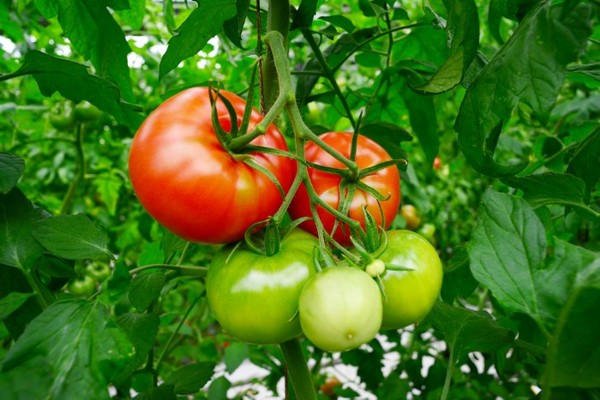

In [72]:
print("Image")
display(Image.open(input_img_path))

In [ ]:
# fig & initialize VLM Tool
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
vlm_tool = VLMTool(api_key=api_key)

# example 1: 모든 객체 탐지
image_path_1 = input_img_path
user_request_1 = "Find all objects in this picture."

img_b64 = encode_image_to_base64(image_path_1)
message1 = [
    {
        "role": "system", 
        "content": "You are an AI assistant that identifies the primary subject for an object detection task from a user's request."},
    {  
        "role": "user", 
        "content": [
            {"type": "text", "text": user_request_1}, 
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img_b64}", "detail": "high"}}]}
]

result = vlm_tool.model_response(message1)
object_1 = vlm_tool.extract_objects_from_request(image_path_1, user_request_1)
print("[Message1] ", f"{result}")
print("\n")
print("[User Request1]: ", f"{user_request_1}")
print("[Detected Object1]: ", f"{object_1}")
print("\n")

# example 2: 토마토의 색 탐지
image_path_2 = input_img_path
user_request_2 = "Find tomatoes's color."
object_2 = vlm_tool.extract_objects_from_request(image_path_2, user_request_2)
print("[User Request2]: ", f"{user_request_2}")
print("[Detected  Object2]: ", f"{object_2}")

[Message1]  The primary objects in this picture are:

1. Tomatoes (at different stages of ripeness: red, green, and light green)
2. Tomato plant stems
3. Tomato plant leaves

The main focus is on the cluster of tomatoes growing on the vine.


[User Request1]:  Find all objects in this picture.
[Detected Object1]:  ['red tomato', 'green tomatoes', 'tomato vine', 'leaves']


[User Request2]:  Find tomatoes's color.
[Detected  Object2]:  ['red', 'green', 'light green']


⸻

### 4. Initial detection & Annotated image visualization

✅ 1단계: Object Detection (원본 이미지 + 개념 리스트 → 박스, 점수, 라벨)
* Input
    * Image
    * Object labels
* Output - 중간 결과
    * detection: [{bbox, score, label}]

✅ 2단계: Annotated Image 생성 (o_grad 추론 → conf/iou 필터 → 픽셀 좌표 → 시각화)
* Input
    * Image
    * initial_detection
* Output
    * annotated_image


In [77]:
class ObjectDetectionTool:
    def __init__(self, model_id, device, vlm_tool, confidence_threshold=0.2, concept_detection_model="gpt-4.1", initial_critique_model="gpt-4o", final_critique_model="gpt-4.1"):
        self.model_id = model_id # owlvit or groungding dino
        self.processor = AutoProcessor.from_pretrained(model_id) # 모델 전처리, 후처리 - 입력 포맷
        self.model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device) # 제로샷 추론 모델 
        self.device = device 
        self.vlm_tool = vlm_tool    
        self.confidence_threshold = confidence_threshold
        self.initial_critique_model = initial_critique_model
        self.final_critique_model = final_critique_model

        # store bounding boxes for potential usage later (e.g., for SAM).
        self.last_detection_bboxes = []
        self.last_filtered_objects = []

In [93]:
def _run_detector(self, image_path, query_list):
    """
    input: image, object query(label)
    output: initial_detection[{bbox, score, label}]
    """
    # === 모델에 맞게 쿼리 수정 === 
    # grounding_dino: "cat. dog. person." 마침표로 구분된 문자열
    if INV_MODEL_TYPES[self.model_id] == "grounding_dino":
        formatted_queries = " ".join([f"{q}." for q in list(query_list)])
    # owl-vit: "An image of {q}", 텍스트 프롬프트 
    elif INV_MODEL_TYPES[self.model_id] == "owlvit":
        formatted_queries = [f"An image of {q}" for q in query_list] 
    else:
        raise NotImplementedError("Model not supported")
    
    # image load: PIL Image, rgb format
    img = Image.open(image_path).convert("RGB") 

    # === input preprocess ===
    inputs = self.processor(
        text=formatted_queries,
        images=img,
        return_tensors="pt", # pytorch tensor
        padding=True,
        truncation=True
    ).to(self.device) # model input format

    # === model inferences === 
    self. model.eval()
    with torch.no_grad():
        outputs = self.model(**inputs)

    # === model input debugging ===
    print("===Input Debugging===")
    print("Formatted queries:", formatted_queries) 
    print("Image size:", img.size) # (width, height)
    print("Inputs keys:", inputs.keys())

    for k, v in inputs.items():
        print(f"{k}: shape={v.shape}, dtype={v.dtype}")
    
    # === model output debugging ===
    print("===Raw Output Debugging===")
    print("Raw model outputs:", outputs)
    print()

    
    # === Result Post-processing: bounding boxes === 
    # grounding dino: CLIP-style query-text alignment 기반, tokenied text(input_ids) 와 logits 비교
    if INV_MODEL_TYPES[self.model_id] == "grounding_dino":
        results = self.processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            target_sizes=[img.size[::-1]]
        )
        boxes = results[0]["boxes"]
        scores = results[0]["scores"]
        labels = results[0]["text_labels"]
    # owl-vit: 토큰 매칭 없이 logits max, [num_boxes, num_queries] - soft matching
    elif INV_MODEL_TYPES[self.model_id] ==  "owlvit": 
        logits = torch.max(outputs["logits"][0], dim=-1)
        scores = torch.sigmoid(logits.values).cpu().numpy()
        labels = logits.indices.cpu().numpy()
        # pred_boxes는 normalized coordinates [0, 1] => scale up to image size
        boxes = outputs["pred_boxes"][0].cpu().numpy()

        # 정규화된 좌표를 픽셀 좌표로 변환
        img_w, img_h = img.size
        boxes[:, [0, 2]] *= img_w  # x1, x2
        boxes[:, [1, 3]] *= img_h  # y1, y2

    else:
        raise NotImplementedError("Model not supported")

    # === Result Debugging === 
    print("===Result Debugging===")
    for i in range(len(boxes)):
        print(f"Box {i}: score={scores[i]:.4f}, label={labels[i]}, box={boxes[i]}")


    # === Result Post-processing: confidence thresholding === 
    # filter condition: score
    detected_objects_final = []
    idx = 1
    for score, box, label in zip(scores, boxes, labels):
        if score < self.confidence_threshold:
            continue
        detected_objects_final.append((idx, label, box.tolist()))
        idx += 1

    # === Draw arrows and numbers ===
    labeled_image_path = draw_arrows_and_numbers(image_path, detected_objects_final)

    # === Final result debugging ===
    print("\n=== Confidence threshold 이상 객체 ===")
    for idx, label, box in detected_objects_final:
        print(f"[{idx}] label: {label}, box: {box}")

    print(f"\n라벨링 이미지 저장 위치: {labeled_image_path}")
    return detected_objects_final, labeled_image_path
ObjectDetectionTool._run_detector = _run_detector
    

Example 1: 모든 객체 탐지 / grounding-dino model

* 이미지–텍스트 입력 기반 Zero-Shot Object Detectio Input/ Rawoutput/ Output 포함
* (AutoProcessor & AutoModel Inference)

VLM 추출 결과: ['tomatoes', 'tomato vine', 'leaves']
===Input Debugging===
Formatted queries: tomatoes. tomato vine. leaves.
Image size: (600, 400)
Inputs keys: KeysView({'pixel_values': tensor([[[[-2.1179, -2.1008, -2.0837,  ..., -1.3473, -1.3473, -1.3473],
          [-2.1179, -2.1008, -2.0665,  ..., -1.4158, -1.3987, -1.3987],
          [-2.1008, -2.0837, -2.0494,  ..., -1.5528, -1.5185, -1.5014],
          ...,
          [-1.6384, -1.6384, -1.6213,  ..., -1.9124, -1.9809, -1.9980],
          [-1.6555, -1.6555, -1.6384,  ..., -1.8953, -1.9638, -1.9980],
          [-1.6555, -1.6555, -1.6384,  ..., -1.8953, -1.9638, -1.9980]],

         [[-0.3901, -0.3550, -0.3025,  ..., -0.4076, -0.4076, -0.4076],
          [-0.3550, -0.3200, -0.2850,  ..., -0.4776, -0.4601, -0.4601],
          [-0.2850, -0.2675, -0.2500,  ..., -0.6352, -0.5826, -0.5826],
          ...,
          [-0.4601, -0.4601, -0.4426,  ..., -0.9503, -1.0203, -1.0378],
          [-0.4776, -0.4776, -0.4601,  ..., -0.9328, -1.0028, -1.

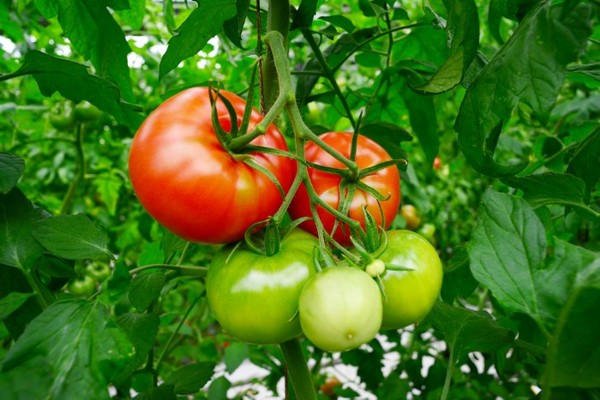


Annotated image:


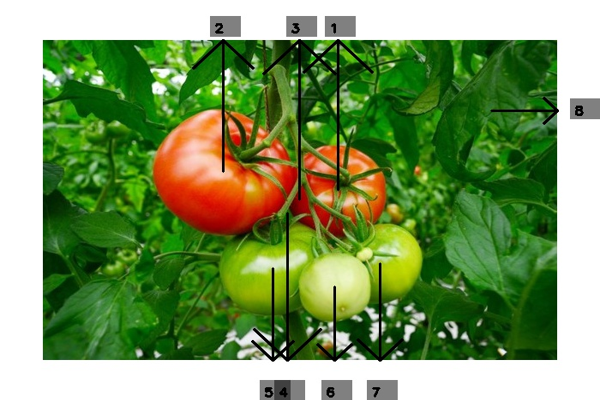

In [85]:
# === 모든 객체 탐지 / detection model: grounding-dino ===

# VLM Tool 초기화
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
vlm_tool = VLMTool(api_key=api_key)

# ObjectDetectionTool 초기화
detector = ObjectDetectionTool(
    model_id=MODEL_ID,  # grounding-dino
    device=DEVICE,      
    vlm_tool=vlm_tool,
    confidence_threshold=CONFIDENCE_THRESHOLD,  # 0.2
    concept_detection_model="gpt-4.1",
    initial_critique_model="gpt-4o",
    final_critique_model="gpt-4.1"
)

# === 테스트 입력 ===
# 이미지 및 사용자 요청
image_path = input_img_path
user_request = "Find all the visible objects in the greenhouse image."

# === VLM으로 객체 후보 추출 ===
query_list = vlm_tool.extract_objects_from_request(image_path, user_request)
print("VLM 추출 결과:", query_list)

# === Detection ===
detected_objects, labeled_image_path = detector._run_detector(image_path, query_list)
print(f"Number of detected object: {len(detected_objects)}")
print(f"Labeled image: {labeled_image_path}")
print(f"Final detections:")
for num, label, bbox in detected_objects:
    x1, y1, x2, y2 = bbox
    print(f"  [{num}] label: {label}, box: ({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})")

# === Visualization === 
# 원본 이미지
print("Original image:")
original_img = Image.open(image_path)
display(original_img.resize((600, 400)))

# 탐지 결과 이미지
print("\nAnnotated image:")
labeled_img = Image.open(labeled_image_path)
display(labeled_img.resize((600, 400)))


Example 2:  일부 객체 탐지 / owl-vit model

VLM 추출 결과: ['red tomatoes']
===Input Debugging===
Formatted queries: ['An image of red tomatoes']
Image size: (600, 400)
Inputs keys: KeysView({'input_ids': tensor([[49406,   550,  2867,   539,   736, 13004, 49407]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]], device='cuda:0'), 'pixel_values': tensor([[[[-1.7923, -1.7631, -1.7047,  ..., -1.1353, -1.1207, -1.1207],
          [-1.7923, -1.7631, -1.7047,  ..., -1.2229, -1.1791, -1.1645],
          [-1.7777, -1.7339, -1.7047,  ..., -1.4127, -1.3105, -1.2667],
          ...,
          [-1.3835, -1.3689, -1.3689,  ..., -1.5587, -1.6317, -1.6901],
          [-1.3981, -1.3835, -1.3835,  ..., -1.5441, -1.6171, -1.6901],
          [-1.3981, -1.3835, -1.3835,  ..., -1.5295, -1.6171, -1.6901]],

         [[-0.3564, -0.2813, -0.2213,  ..., -0.3264, -0.3414, -0.3414],
          [-0.3114, -0.2663, -0.2213,  ..., -0.4164, -0.4014, -0.3864],
          [-0.2513, -0.2213, -0.2063,  ..., -0.6115, -0.5515, -0.5065],
          ...,
 

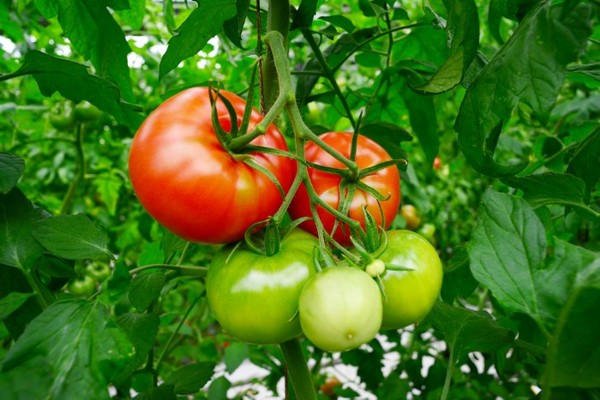


Annotated image:


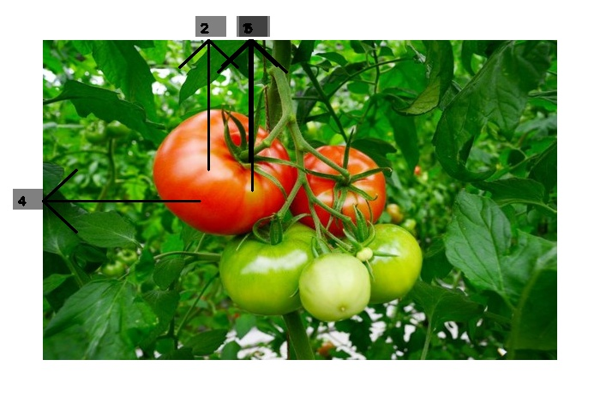

In [99]:
# ===  일부 객체 탐지 / owl-vit model ===
# VLM Tool 초기화
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
vlm_tool = VLMTool(api_key=api_key)

# ObjectDetectionTool 초기화
detector = ObjectDetectionTool(
    model_id = MODEL_TYPES["owlvit"],  # grounding-dino
    device=DEVICE,      
    vlm_tool=vlm_tool,
    confidence_threshold=CONFIDENCE_THRESHOLD,  # 0.2
    concept_detection_model="gpt-4.1",
    initial_critique_model="gpt-4o",
    final_critique_model="gpt-4.1"
)

# === 테스트 입력 ===
# 이미지 및 사용자 요청
image_path = input_img_path
user_request = "Find red tomatoes in this image."

# === VLM으로 객체 후보 추출 ===
query_list = vlm_tool.extract_objects_from_request(image_path, user_request)
print("VLM 추출 결과:", query_list)

# === Detection ===
detected_objects, labeled_image_path = detector._run_detector(image_path, query_list)
print(f"Number of detected object: {len(detected_objects)}")
print(f"Labeled image: {labeled_image_path}")
print(f"Final detections:")
for num, label, bbox in detected_objects:
    x1, y1, x2, y2 = bbox
    print(f"  [{num}] label: {label}, box: ({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})")

# === Visualization === 
# 원본 이미지
print("Original image:")
original_img = Image.open(image_path)
display(original_img.resize((600, 400)))

# 탐지 결과 이미지
print("\nAnnotated image:")
labeled_img = Image.open(labeled_image_path)
display(labeled_img.resize((600, 400)))


=== Debugging ===

* Model: Owl ViT 

* Inputs keys: KeysView({'input_ids', 'attention_mask', 'pixel_values'})
    * input_ids
        * query -> tokenize -> index(BERT format)
        * 각 행이 하나의 쿼리 문장
        * 토크나이저가 문장을 단어 단위로 분해한 후 사전에 매칭한 token
        * ```python
            'input_ids': 
                tensor([
                    [49406,   550,  2867,   539,  9867, 49407],  # An image of tomato
                    [49406,   550,  2867,   539,  7232, 49407],  # An image of leaf
                    [49406,   550,  2867,   539,  6761, 49407]   # An image of stem
                ])
            ```

    * attention_mask
        * padding 0, valid token 1 -> masked vector
        * ```python
            'attention_mask':
                tensor([
                    [1, 1, 1, 1, 1, 1], # An image of tomato
                    [1, 1, 1, 1, 1, 1], # An image of leaf
                    [1, 1, 1, 1, 1, 1] # An image of stem
                ])
            ```

    * pixel_values
        * VLM에 입력되는 이미지 데이터 - 전처리되어 모델이 학습한 형식에 맞춘 텐서
        * tensor [batch, channel, height, width]: ([1, 3, 768, 768])
        * 한 장의 RGB 이미지를 768*768 크기로 바꿔서 입력으로 사용
        * 이미지의 픽셀을 [-1, 1] 범위로 정규화
        * ```python
            'pixel_values': tensor([[[[
                -0.9164, -0.9164, -0.9164,  ..., -1.2083, -1.1791, -1.1499],
                [-0.9018, -0.9018, -0.9018,  ..., -1.1937, -1.1791, -1.1645],
                [-0.9164, -0.9018, -0.8872,  ..., -1.2083, -1.2083, -1.2083],
                ...,
                [-1.3981, -1.3689, -1.3543,  ..., -1.2959, -1.2959, -1.2959],
                [-1.3981, -1.3981, -1.3689,  ..., -1.2959, -1.2959, -1.3105],
                [-1.3543, -1.3543, -1.3543,  ..., -1.2813, -1.2959, -1.3251]
            ]]])
            ```

* Raw output 
    * zero-shot object detection을 수행한 결과
    * 다양한 필드의 텐서를 포함한 구조체

* Output
    * 
    * confidence 이상 객체

owlvit model: 쿼리가 추상적이거나 길 경우 정확하게 매핑하지 못할 수 있음. red에 반응하지 못하거나 tomato만 학습될 수 있음

⸻

### 5. Critique & Refine

In [ ]:
# === Critique/Refine ===
# “너무 구체/오분류 라벨→상위 개념 일반화”를 요청



### 6. Second detection

In [ ]:
# === 2차 detection ===


### 7. Validation

In [ ]:
# === 최종 validation ===
# 최종 검증 모델(gpt-4o)에 유효한 객체 번호 제시 -> 최종 박스 좌표 출력

### 8. Final output

In [ ]:
# 결과 정리 

In [ ]:
# 실험 체크리스트 
# 개념 추출이 “명시 vs 나열” 모두 잘 동작하는지
# 1차 탐지 → 비평 → 2차 탐지가 있을 때 성능이 개선되는지
# 숫자 배칭 한 번만으로 모든 박스를 검증 가능(박스별 크롭을 다수 요청하는 것보다 효율적)함을 확인